## Introducción

Como analista de datos, tu objetivo es **evaluar cómo la movilidad urbana se relaciona con la productividad económica en las principales ciudades latinoamericanas**. 
Para ello trabajarás con datos reales de TomTom Traffic Index y OECD Cities, que deberás limpiar, combinar y analizar para identificar en qué ciudades conviene invertir en infraestructura de transporte.

## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de ambos datasets**.
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯Objetivo:**
Importar las librerías necesarias, cargar los archivos CSV en DataFrames y realizar una revisión preliminar para entender su contenido.

**Instrucciones:**
- Importa las librerías `pandas`, `numpy`, `seaborn` y `matplotlib.pyplot`.
- Carga los archivos usando `pd.read_csv()`:
  - `'/datasets/tomtom_traffic.csv'`
  - `/datasets/oecd_city_economy.csv` `.
- Guarda los DataFrames en las variables `traffic` y `eco`.
- Muestra las primeras 5 filas de cada DataFrame.


In [3]:
# importar librerías
# Pandas
import pandas as pd
# Numpy
import numpy as np
# Seaborn
import seaborn as sns
# Matplotlib
import matplotlib.pyplot as plt

In [4]:
# cargar archivos
traffic = pd.read_csv('tomtom_traffic.csv')
eco = pd.read_csv('oecd_city_economy.csv')  

In [5]:
# mostrar las primeras 5 filas de traffic
traffic.head()

,Country,City,UpdateTimeUTC,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,UpdateTimeUTCWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232
3,ARE,abu-dhabi,2025-01-13 01:46:30.001,8.2,2.0,4.1,2.0,2.0,2025-01-06 01:46:30.000,7.723808,7.899046,-0.175238
4,ARE,abu-dhabi,2025-01-13 00:01:30.000,1.1,1.0,0.2,1.0,1.0,2025-01-06 00:01:30.000,8.336363,8.604379,-0.268016


In [6]:
# mostrar las primeras 5 filas de eco
eco.head()

,Year,City,Country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M)
0,2023,buenos-aires,Argentina,"15.782,00",6.2%,"15,2","15,30"
1,2023,sao-paulo,Brazil,"14.475,00",9.1%,"29,50","22,50"
2,2023,rio-de-janeiro,Brazil,"13.142,00",9.8%,"19,10","13,60"
3,2023,brasilia,Brazil,"15.999,00",8.3%,"13,50","4,70"
4,2023,salvador,Brazil,"8.761,00",13.1%,"16,00","3,90"


**Tip:** Si no usas `print()` la tabla se vera mejor.


---

## 🧩Paso 2: Explorar, limpiar y preparar los datos

Antes de combinar los datasets, inspecciona su estructura, tipos de datos, columnas y valores faltantes.
Anota las columnas que necesiten limpieza y luego estandariza los nombres de columnas.

### 2.1 Explorar la estructura y tipos de datos

**🎯Objetivo:**
Identificar columnas con tipos incorrectos, distribución y nulos, anotar las columnas que requieren conversión.

**Instrucciones:**

- Usa `.info()` para conocer la estructura de ambos DataFrames.
- Muestra los primeros 3 renglones de cada DF.
- Identifica si los detalles de cada DF estan bien o si requieren correcciones y escribe tus conclusiones en el bloque Markdown.
  - ¿Hay columnas que requieren conversión?¿ Cuáles son? ¿Que tipo de dato tienen y cuál deberían de tener?
  - ¿Hay datos ausentes en alguna columna?

In [7]:
# Examinar la estructura de traffic

# Imprime un título para identificar la sección del DataFrame traffic
print("=== traffic ===")

# Muestra información general del DataFrame traffic:
# número de filas, columnas, tipos de datos y valores no nulos
traffic.info()

# Imprime un salto de línea y un texto descriptivo
print("\nPrimeras 3 filas de traffic:")

# Muestra las primeras 3 filas del DataFrame traffic
traffic.head(3)

=== traffic ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   Country                         1004464 non-null  object 
 1   City                            1004464 non-null  object 
 2   UpdateTimeUTC                   1004464 non-null  object 
 3   JamsDelay                       1004464 non-null  float64
 4   TrafficIndexLive                1004464 non-null  float64
 5   JamsLengthInKms                 1004464 non-null  float64
 6   JamsCount                       1004464 non-null  float64
 7   TrafficIndexWeekAgo             1004464 non-null  float64
 8   UpdateTimeUTCWeekAgo            1004464 non-null  object 
 9   TravelTimeLivePer10KmsMins      1004464 non-null  float64
 10  TravelTimeHistoricPer10KmsMins  1004464 non-null  float64
 11  MinsDelay                       1004464 non-nul

,Country,City,UpdateTimeUTC,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,UpdateTimeUTCWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232


En la estructura del traffic, se observa que:
- 
### Estructura general
- El DataFrame tiene **1,004,464 registros** y **12 columnas**.
- Las columnas principales que identifican cada registro son: `Country`, `City`, `UpdateTimeUTC`.

### Columnas que requieren conversión
- `UpdateTimeUTC` y `UpdateTimeUTCWeekAgo` → actualmente son `object` (strings).  
  **Deberían convertirse a `datetime`** para facilitar análisis temporal (filtrar por fechas, calcular diferencias, etc.).

### Columnas con tipos correctos
- `Country` y `City` → `object` (strings). Correcto para identificadores textuales.
- Métricas (`JamsDelay`, `TrafficIndexLive`, `JamsLengthInKms`, `JamsCount`, `TrafficIndexWeekAgo`, `TravelTimeLivePer10KmsMins`, `TravelTimeHistoricPer10KmsMins`, `MinsDelay`) → todas en `float64`. Correcto para cálculos numéricos.

### Datos ausentes
- Según `.info()`, **no hay valores nulos** en ninguna columna (`Non-Null Count` = número total de registros).
- Esto indica que el dataset está completo, al menos en términos de presencia de datos.

### Conclusión
- La estructura está bien definida y las métricas tienen el tipo de dato adecuado.  
- **Corrección necesaria:** convertir las columnas de fecha (`UpdateTimeUTC`, `UpdateTimeUTCWeekAgo`) a `datetime`.  
- No se detectan datos ausentes, lo cual facilita el análisis sin necesidad de imputación o limpieza adicional.


In [8]:
# Examinar la estructura de eco

# Imprime un título para identificar la sección del DataFrame eco
print("=== eco ===")

# Muestra información general del DataFrame eco:
# número de filas, columnas, tipos de datos y valores no nulos
eco.info()

# Imprime un salto de línea y un texto descriptivo
print("\nPrimeras 3 filas de eco:")

# Muestra las primeras 3 filas del DataFrame eco
eco.head(3)

=== eco ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Year             30 non-null     int64 
 1   City             30 non-null     object
 2   Country          30 non-null     object
 3   City GDP/capita  30 non-null     object
 4   Unemployment %   30 non-null     object
 5   PM2.5 (μg/m³)    30 non-null     object
 6   Population (M)   30 non-null     object
dtypes: int64(1), object(6)
memory usage: 1.8+ KB

Primeras 3 filas de eco:


,Year,City,Country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M)
0,2023,buenos-aires,Argentina,"15.782,00",6.2%,"15,2","15,30"
1,2023,sao-paulo,Brazil,"14.475,00",9.1%,"29,50","22,50"
2,2023,rio-de-janeiro,Brazil,"13.142,00",9.8%,"19,10","13,60"


En la estructura del eco, se observa que:
- 
### Estructura general
- El DataFrame tiene **30 registros** y **7 columnas**.
- Llaves principales: `(Year, Country, City)` identifican cada fila.

### Columnas que requieren conversión
- `City GDP/capita` → actualmente `object` (string con separador de miles y coma decimal).  
  **Debería ser `float`** para cálculos económicos.  
  Ejemplo: `"15.782,00"` → `15782.00`.

- `Unemployment %` → actualmente `object` (string con símbolo `%`).  
  **Debería ser `float`** para análisis estadístico.  
  Ejemplo: `"6.2%"` → `6.2`.

- `PM2.5 (μg/m³)` → actualmente `object` (string con coma decimal).  
  **Debería ser `float`** para análisis ambiental.  
  Ejemplo: `"15,2"` → `15.2`.

- `Population (M)` → actualmente `object` (string con coma decimal).  
  **Debería ser `float`** para cálculos demográficos.  
  Ejemplo: `"15,30"` → `15.30`.

### Columnas con tipos correctos
- `Year` → `int64`. Correcto.  
- `City` y `Country` → `object` (strings). Correcto.

### Datos ausentes
- Según `.info()`, **no hay valores nulos** (`Non-Null Count` = 30 en todas las columnas).  
- El dataset está completo en términos de presencia de datos.

### Conclusión
- La estructura es consistente, pero **las métricas numéricas están mal tipadas como `object`**.  
- Se requiere conversión de `City GDP/capita`, `Unemployment %`, `PM2.5 (μg/m³)` y `Population (M)` a `float`.  
- No se detectan datos ausentes, lo que facilita el análisis una vez corregidos los tipos de datos.

### 2.2 Renombrar columnas

**🎯Objetivo:**
Estandarizar los nombres de columnas para evitar errores y facilitar la unión de los datasets.

**Instrucciones:**

- Cambia los nombres de las columnas para que tengan el formato `snake_case`.
    - `Country` → `country`
    - `UpdateTimeUTC` → `update_time_utc`
- Verifica que los cambios se hayan aplicado correctamente usando `.columns`.


In [9]:
# Estandarizar los nombres de las columnas de traffic

# Renombrar columnas de traffic a snake_case
traffic = traffic.rename(columns={
    "Country": "country",
    "City": "city",
    "UpdateTimeUTC": "update_time_utc",
    "JamsDelay": "jams_delay",
    "TrafficIndexLive": "traffic_index_live",
    "JamsLengthInKms": "jams_length_in_kms",
    "JamsCount": "jams_count",
    "TrafficIndexWeekAgo": "traffic_index_week_ago",
    "UpdateTimeUTCWeekAgo": "update_time_utc_week_ago",
    "TravelTimeLivePer10KmsMins": "travel_time_live_per_10kms_mins",
    "TravelTimeHistoricPer10KmsMins": "travel_time_historic_per_10kms_mins",
    "MinsDelay": "mins_delay"
})
# verificar cambios
traffic.columns

Index(['country', 'city', 'update_time_utc', 'jams_delay',
       'traffic_index_live', 'jams_length_in_kms', 'jams_count',
       'traffic_index_week_ago', 'update_time_utc_week_ago',
       'travel_time_live_per_10kms_mins',
       'travel_time_historic_per_10kms_mins', 'mins_delay'],
      dtype='object')

In [10]:
# Estandarizar los nombres de las columnas de eco

# Renombrar columnas de eco a snake_case
eco = eco.rename(columns={
    "Year": "year",
    "City": "city",
    "Country": "country",
    "City GDP/capita": "city_gdp_per_capita",
    "Unemployment %": "unemployment_percent",
    "PM2.5 (μg/m³)": "pm25_ug_m3",
    "Population (M)": "population_millions"
})

# verificar cambios
eco.columns

Index(['year', 'city', 'country', 'city_gdp_per_capita',
       'unemployment_percent', 'pm25_ug_m3', 'population_millions'],
      dtype='object')


### 2.3 Corregir formatos numéricos y de fecha

**🎯Objetivo:**
Asegurar que las columnas de fechas y valores numéricos estén en formatos correctos para permitir análisis, cálculos y comparaciones precisas.

**Instrucciones:**

- Convierte las columnas de fecha de `traffic` a formato `datetime`. Haz el cambio a prueba de errores.
- En el dataset `eco`, limpia los valores numéricos:
    - En `city_gdp_capita`: elimina separadores de miles (`.`) y reemplaza las comas (`','`) por puntos (`'.'`) antes de convertir a tipo `float`.
    - En `unemployment_pct`: elimina el símbolo de porcentaje (`%`) y reemplaza las comas (`','`) por puntos (`'.'`) antes de convertir a tipo `float`.
    - En `population_m`: reemplaza las comas (`','`) por puntos (`'.'`) antes de convertir a tipo `float`.
- Finalmente, crea una nueva columna llamada `population` multiplicando `population_m` por 1,000,000 para obtener la población total.


In [11]:
# Convertir las columnas de traffic a tipo fecha con pd.to_datetime()

traffic['update_time_utc'] = pd.to_datetime(traffic['update_time_utc'])
traffic['update_time_utc_week_ago'] = pd.to_datetime(traffic['update_time_utc_week_ago'])

# verificar el cambio
traffic.info()
traffic.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                               Non-Null Count    Dtype         
---  ------                               --------------    -----         
 0   country                              1004464 non-null  object        
 1   city                                 1004464 non-null  object        
 2   update_time_utc                      1004464 non-null  datetime64[ns]
 3   jams_delay                           1004464 non-null  float64       
 4   traffic_index_live                   1004464 non-null  float64       
 5   jams_length_in_kms                   1004464 non-null  float64       
 6   jams_count                           1004464 non-null  float64       
 7   traffic_index_week_ago               1004464 non-null  float64       
 8   update_time_utc_week_ago             1004464 non-null  datetime64[ns]
 9   travel_time_live_per_10kms_mins      1004464 non-null  fl

,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins,mins_delay
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232


In [12]:
print(eco.columns)

Index(['year', 'city', 'country', 'city_gdp_per_capita',
       'unemployment_percent', 'pm25_ug_m3', 'population_millions'],
      dtype='object')


In [13]:
# Limpiar separadores y convertir columnas numéricas

# Usamos .astype(str) para asegurar que el replace funcione incluso si ya hay floats
eco['city_gdp_per_capita'] = eco['city_gdp_per_capita'].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False).astype(float)
eco['unemployment_percent'] = eco['unemployment_percent'].astype(str).str.replace('%', '', regex=False).str.replace(',', '.', regex=False).astype(float)
eco['pm25_ug_m3'] = eco['pm25_ug_m3'].astype(str).str.replace(',', '.', regex=False).astype(float)
eco['population_millions'] = eco['population_millions'].astype(str).str.replace(',', '.', regex=False).astype(float)

# Calcular la población total en unidades absolutas (millones * 1,000,000)
eco['population'] = eco['population_millions'] * 1_000_000

# Verificar cambios
eco.info()
eco.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  30 non-null     int64  
 1   city                  30 non-null     object 
 2   country               30 non-null     object 
 3   city_gdp_per_capita   30 non-null     float64
 4   unemployment_percent  30 non-null     float64
 5   pm25_ug_m3            30 non-null     float64
 6   population_millions   30 non-null     float64
 7   population            30 non-null     float64
dtypes: float64(5), int64(1), object(2)
memory usage: 2.0+ KB


,year,city,country,city_gdp_per_capita,unemployment_percent,pm25_ug_m3,population_millions,population
0,2023,buenos-aires,Argentina,15782.0,6.2,15.2,15.3,15300000.0
1,2023,sao-paulo,Brazil,14475.0,9.1,29.5,22.5,22500000.0
2,2023,rio-de-janeiro,Brazil,13142.0,9.8,19.1,13.6,13600000.0



---

## 🧩Paso 3: Extraer año y filtrar

Extraer el año permite filtrar la información y trabajar solo con el período más reciente y relevante.

### 3.1 Extraer columna año y filtrar 2024

**🎯Objetivo**
Identificar el año de cada registro y mantener solo los registros del 2024.

**Intrucciones**

- Como el DataFrame `traffic` no tiene una columna de año, utiliza el atributo `.dt.year` sobre su columna de fecha para crear una nueva columna llamada `year`.
- Filtra las filas donde el año sea **2024**.
- Utiliza `.copy()` para crear dos nuevos DataFrames (`traffic_2024` y `eco_2024`) para evitar modificar el dataset original.

In [14]:
# Crear copia de traffic para trabajar sin modificar el original
traffic_copy = traffic.copy()

# Extraer el año de las fechas en update_time_utc
traffic_copy['year'] = traffic_copy['update_time_utc'].dt.year

# Mover la columna 'year' al inicio
cols = ['year'] + [col for col in traffic_copy.columns if col != 'year']
traffic_copy = traffic_copy[cols]

# Filtrar los registros del año 2024 
traffic_2024 = traffic_copy[traffic_copy['year'] == 2024]

# Verificar cambio
traffic_2024.head(3)

,year,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins,mins_delay
302,2024,ARE,abu-dhabi,2024-12-31 23:01:30,12.9,5.0,2.5,5.0,2.0,2024-12-24 23:01:30.001,8.560399,8.519634,0.040765
303,2024,ARE,abu-dhabi,2024-12-31 22:01:30,136.0,21.0,20.6,32.0,3.0,2024-12-24 22:01:30.000,10.355732,9.049445,1.306286
304,2024,ARE,abu-dhabi,2024-12-31 21:16:30,455.2,31.0,40.4,72.0,4.0,2024-12-24 21:01:30.000,11.456878,9.305174,2.151704


In [15]:
# Filtrar los registros del año 2024 y crear copia
eco_2024 = eco[eco['year'] == 2024].copy()

# Revisar dataframes nuevos
display(traffic_2024.head())
display(eco_2024.head())

,year,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins,mins_delay
302,2024,ARE,abu-dhabi,2024-12-31 23:01:30.000,12.9,5.0,2.5,5.0,2.0,2024-12-24 23:01:30.001,8.560399,8.519634,0.040765
303,2024,ARE,abu-dhabi,2024-12-31 22:01:30.000,136.0,21.0,20.6,32.0,3.0,2024-12-24 22:01:30.000,10.355732,9.049445,1.306286
304,2024,ARE,abu-dhabi,2024-12-31 21:16:30.000,455.2,31.0,40.4,72.0,4.0,2024-12-24 21:01:30.000,11.456878,9.305174,2.151704
305,2024,ARE,abu-dhabi,2024-12-31 20:01:00.001,399.4,27.0,38.0,75.0,6.0,2024-12-24 20:01:30.001,11.670062,9.952811,1.717252
306,2024,ARE,abu-dhabi,2024-12-31 19:46:00.000,366.4,28.0,39.8,82.0,9.0,2024-12-24 19:01:00.000,11.686322,10.008469,1.677853


,year,city,country,city_gdp_per_capita,unemployment_percent,pm25_ug_m3,population_millions,population
15,2024,buenos-aires,Argentina,18117.0,7.2,14.5,15.4,15400000.0
16,2024,sao-paulo,Brazil,14703.0,8.5,28.0,22.6,22600000.0
17,2024,rio-de-janeiro,Brazil,13349.0,9.2,18.4,13.7,13700000.0
18,2024,brasilia,Brazil,16251.0,7.8,12.8,4.8,4800000.0
19,2024,salvador,Brazil,8899.0,12.4,15.2,3.9,3900000.0



---

## 🧩Paso 4: Analizar y resumir datos de movilidad

Como el dataset de tráfico contiene **múltiples registros por ciudad**. En esta parte, calcularás los promedios anuales por ciudad para simplificar el análisis y obtener una visión más clara de las tendencias generales.

### 4.1 Calcular promedios de tráfico por ciudad

**🎯Objetivo:**
Obtener una vista consolidada del tráfico promedio por ciudad y año, para analizar patrones generales sin depender de datos diarios.

**Instrucciones**

- Agrupa los datos por `city`, `country` y `year`.
- Calcula el promedio **solo de las métricas de tráfico más relevantes**: como `jams_delay`, `traffic_index_live`, `jams_length_kms`, `jams_count`, `mins_delay`, y tiempos de viaje (`travel_time_live_per_10kms_mins` y `travel_time_hist_per_10kms_mins`).
- Guarda el resultado como `traffic_city_year_2024`, mantén las columnas como variables (no índices).


In [16]:
# Calcular los promedios de tráfico por ciudad, país y año (solo 2024)
traffic_city_year_2024 = (
    traffic_2024
    .groupby(['city', 'country', 'year'])
    .agg({
        'jams_delay': 'mean',
        'traffic_index_live': 'mean',
        'jams_length_in_kms': 'mean',
        'jams_count': 'mean',
        'mins_delay': 'mean',
        'travel_time_live_per_10kms_mins': 'mean',
        'travel_time_historic_per_10kms_mins': 'mean'
    })
    .reset_index()
)

# Mostrar resultado
traffic_city_year_2024.head()

,city,country,year,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins
0,a-coruna,ESP,2024,17.935187,15.259774,2.198002,4.934405,0.774172,16.267977,15.493804
1,aachen,DEU,2024,26.732141,20.960314,3.892586,6.601832,0.792968,13.397861,12.604894
2,aarhus,DNK,2024,21.200616,16.575891,2.736736,6.109987,0.495276,15.219292,14.724016
3,abu-dhabi,ARE,2024,171.157315,13.902028,24.507380,47.268019,0.139764,9.829092,9.689328
4,adana,TUR,2024,83.864761,22.541040,11.827331,23.754620,1.129749,15.879694,14.749945


### 🧠 **Momento de reflexión**

¡Excelente trabajo hasta aquí!

Ahora que ya tienes los promedios anuales por ciudad, es momento de **observarlos** con atención.

Piensa:

- ¿Cuál crees que tiene el mayor tiempo promedio de tráfico?
- ¿Será una ciudad de **Europa**, de **Latinoamérica** o de **otra región** del mundo?

Para descubrirlo, ejecuta esta línea de código:

`traffic_city_year_2024.sort_values(["jams_delay"], ascending=False)`


🔍 Observa qué ciudad aparece en los primeros lugares.

¿Te sorprenden los resultados? , ¿Coinciden con lo que imaginabas?

In [17]:
traffic_city_year_2024.sort_values(["jams_delay"], ascending=False)

,city,country,year,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins
221,mexico-city,MEX,2024,2833.057892,34.218190,389.239265,594.969392,1.855542,21.809092,19.953550
352,tokyo,JPN,2024,2152.574357,36.805059,373.069734,518.809420,0.698152,22.443778,21.745626
246,new-york,USA,2024,2133.400000,28.210388,398.227892,544.474902,1.396351,18.505043,17.108691
200,london,GBR,2024,2050.703662,29.230166,287.632868,471.795554,1.325160,17.714139,16.388979
211,manila,PHL,2024,1741.493381,66.129402,246.858082,341.881205,2.469894,27.134629,24.664734
...,...,...,...,...,...,...,...,...,...,...
111,dunedin,NZL,2024,4.651175,15.430809,0.712315,1.591384,0.633294,16.226009,15.592715
363,uppsala,SWE,2024,4.194486,13.939168,0.656368,1.349672,0.501802,15.746717,15.244916
123,fujairah,ARE,2024,4.025959,10.907719,0.731910,1.373006,0.194951,11.662590,11.467639
12,almere,NLD,2024,3.633523,6.290478,0.506362,1.064063,-0.017544,9.467150,9.484694


La ciudad con el mayor tiempo promedio de tráfico es manila con un tiempo promedio real de viaje por cada 10 kilómetro de 27.13 min por cada 10 km


---

## 🧩Paso 5: Unir movilidad y economía

Combinar datasets te permite analizar cómo se relacionan los indicadores económicos con los de movilidad.

### 5.1 Unir tráfico (tabla principal) con indicadores económicos

**🎯Objetivo:**
Combinar la información de tráfico y economía en un solo DataFrame para analizar cómo las condiciones económicas se relacionan con la movilidad urbana.

**Instrucciones**
- Selecciona solo las **columnas relevantes** de cada dataset (por ejemplo, variables clave de tráfico y de economía).
- Usa `.copy()` al crear subconjuntos para evitar modificar el dataset original.
- Une ambos DataFrames y define como **claves de unión** a `city` y `year`.
- Mantén solo las ciudades y años presentes en ambos datasets.
- Guarda el resultado en una nueva variable llamada `merged` y muestra las primeras 5 filas.


In [18]:
# Seleccionar columnas clave de tráfico y economía
left_cols = ['year','city','country','jams_delay','traffic_index_live',
             'jams_length_in_kms','jams_count','mins_delay',
             'travel_time_live_per_10kms_mins','travel_time_historic_per_10kms_mins']

right_cols = ['city','year','city_gdp_per_capita','unemployment_percent','pm25_ug_m3','population_millions']

# Usar .copy() para crear los dos nuevos datasets reducidos
traffic_2024_small = traffic_city_year_2024[left_cols].copy()
eco_2024_small = eco_2024[right_cols].copy()

# Unir datasets con claves city y year
merged = pd.merge(
    traffic_2024_small,
    eco_2024_small,
    on=['city','year'],
    how='inner'   # Mantiene solo las ciudades y años presentes en ambos
)

# Mostrar las primeras 5 filas
display(merged)

,year,city,country,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins,city_gdp_per_capita,unemployment_percent,pm25_ug_m3,population_millions
0,2024,belo-horizonte,BRA,263.047879,19.428946,44.038129,68.805422,0.487228,18.304538,17.817311,11124.0,9.5,16.8,6.1
1,2024,bogota,COL,1141.552364,37.614273,140.893564,230.566550,1.699628,24.992185,23.292557,11442.0,10.0,17.6,11.3
2,2024,brasilia,BRA,101.576326,11.258220,18.337133,27.280140,0.193442,13.338658,13.145216,16251.0,7.8,12.8,4.8
3,2024,buenos-aires,ARG,571.089593,17.756012,100.287844,137.359860,0.416566,17.907916,17.491349,18117.0,7.2,14.5,15.4
4,2024,curitiba,BRA,183.469274,14.954545,30.050044,46.898164,0.139965,17.258700,17.118736,12381.0,8.2,13.5,3.7
5,2024,fortaleza,BRA,82.813181,15.896749,11.205844,24.644991,0.081618,19.267171,19.185554,8512.0,11.8,14.6,4.2
6,2024,lima,PER,1052.292789,31.031277,110.314770,213.453519,1.506305,25.674261,24.167956,13472.0,6.5,19.7,11.2
7,2024,mexico-city,MEX,2833.057892,34.218190,389.239265,594.969392,1.855542,21.809092,19.953550,21111.0,3.2,22.3,22.1
8,2024,montevideo,URY,50.201092,17.014854,6.369201,14.160332,0.393442,18.892342,18.498900,26176.0,8.4,11.2,1.8
9,2024,porto-alegre,BRA,139.382830,17.687254,20.167849,39.813403,0.194195,16.166684,15.972490,11801.0,8.7,14.2,4.3



---

## 🧩Paso 6: Visualización y análisis de relaciones

Ahora que tienes un dataset limpio y unificado, es momento de **visualizar patrones**.
Los gráficos te ayudarán a entender cómo se relacionan las variables económicas con las de movilidad urbana.

### 6.1 Visualizar relaciones entre economía y tráfico

**🎯Objetivo:**
Analizar visualmente la distribución y la relación entre indicadores de tráfico y economía en 2024, para identificar posibles patrones o tendencias generales entre ambas variables.

**Instrucciones**
- Usa las librerías `seaborn` y `matplotlib.pyplot` para generar los gráficos.
- Visualiza la distribución del **tráfico** (`jams_delay`) mediante:
    - **Boxplot** → para observar la media, mediana y detectar valores atípicos.
- Visualiza la distribución de la **economía** (`city_gdp_capita`) mediante:
    - **Histograma** → para analizar la forma de la distribución y el valor promedio del PIB per cápita.
- Finalmente, **compara ambas variables**, para observar si existe alguna relación entre ellas, haciendo un solo gráfico de barras donde aparezcan ambos indicadores.
- Recuerda agregar título y etiquetas a los ejes de tus gráficos.
- Observa y comenta los patrones, valores extremos o posibles relaciones que identifiques.

**Tip:** Dentro de los parentesis del boxplot, agrega `showmeans=True` para ver la media en el gráfico.

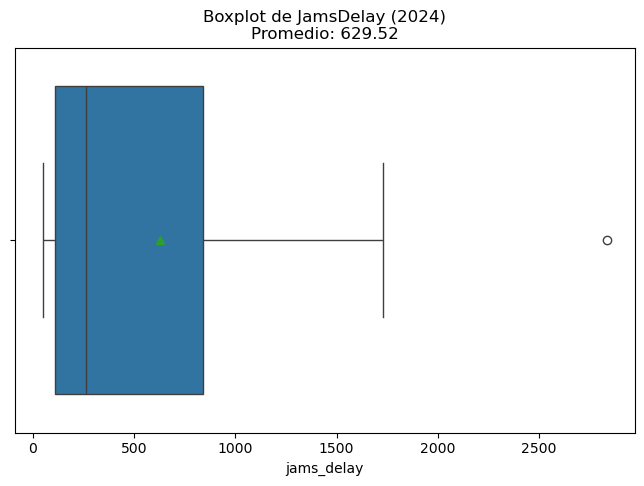

In [19]:
# Crear boxplot para observar el comportamiento de los minutos de congestion JamsDelay
plt.figure(figsize=(8,5))
sns.boxplot(x=merged['jams_delay'], showmeans=True)

# obtener promedio para mostrarlo en título
mean_value = merged['jams_delay'].mean()
plt.title(f'Boxplot de JamsDelay (2024)\nPromedio: {mean_value:.2f}')
plt.show()

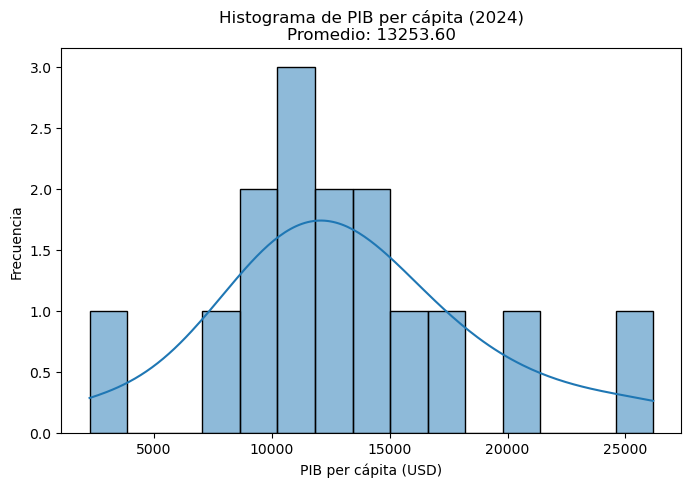

In [20]:
# Crear histograma para ver la distribución de la economía (city_gdp_per_capita)
plt.figure(figsize=(8,5))
sns.histplot(merged['city_gdp_per_capita'], bins=15, kde=True)
mean_gdp = merged['city_gdp_per_capita'].mean()
plt.title(f'Histograma de PIB per cápita (2024)\nPromedio: {mean_gdp:.2f}')
plt.xlabel('PIB per cápita (USD)')
plt.ylabel('Frecuencia')
plt.show()

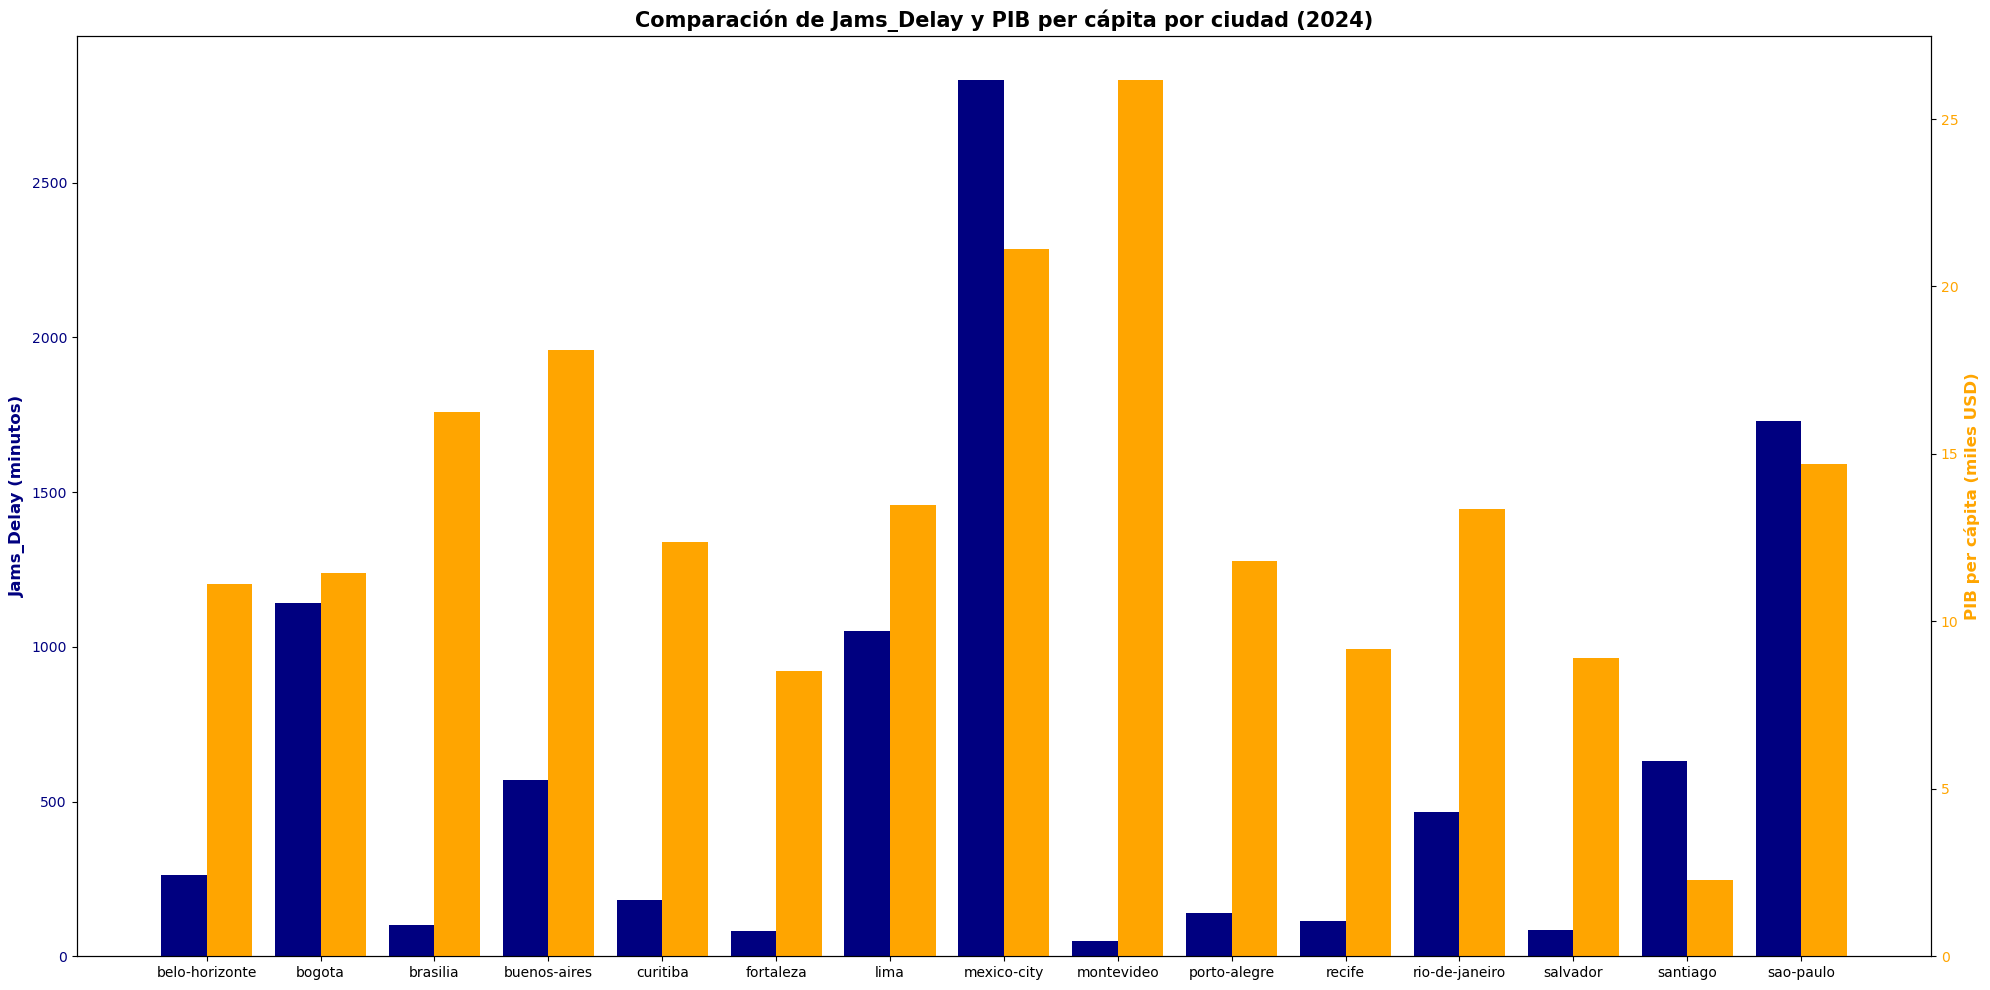

In [ ]:
# Gráfico de barras para comparar jams_delay y city_gdp_per_capita por ciudad

bar_width = 0.4
cities = merged['city']
x = range(len(cities))

fig, ax1 = plt.subplots(figsize=(20,10))  # tamaño del grafico

# Primer eje Y: jams_delay (azul oscuro)
ax1.bar(x, merged['jams_delay'], width=bar_width, label='Jams_Delay (minutos)', color='navy')
ax1.set_ylabel('Jams_Delay (minutos)', color='navy', fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor='navy')

# Segundo eje Y: PIB per cápita (naranja, en miles de USD)
ax2 = ax1.twinx()
ax2.bar([i + bar_width for i in x], merged['city_gdp_per_capita']/1000, 
        width=bar_width, label='PIB per cápita (miles USD)', color='orange')
ax2.set_ylabel('PIB per cápita (miles USD)', color='orange', fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor='orange')

# Etiquetas y título
plt.xticks([i + bar_width/2 for i in x], cities, rotation=90, fontsize=10, fontweight='bold')
plt.title('Comparación de Jams_Delay y PIB per cápita por ciudad (2024)', fontsize=15, fontweight='bold')
fig.tight_layout()
plt.show()

**Tip:** Antes del `plt.show()` agrega el código `plt.xticks(rotation=90)` para rotar las etiquetas del eje X en 90 grados.

### 🧠 **Reflexiona**
Excelente trabajo llegando a esta etapa del análisis. Antes de avanzar, revisa tus gráficos, tómate un momento para pensar:


* ¿Las ciudades con mayor PIB per cápita también presentan más congestión?

* ¿O sucede lo contrario, o no existe una relación clara?


El PIB per cápita no guarda una relación directa con la congestión: Montevideo, con el PIB más alto, apenas sufre retrasos, mientras que Ciudad de México combina un PIB elevado con la peor congestión. por otro lado Santiago, con un PIB bajo, muestra niveles de tráfico significativamente alto. Esto nos dice que la riqueza económica por habitante no explica por sí sola la movilidad urbana; más bien, factores como el tamaño poblacional, la calidad de la infraestructura vial y la planificación urbana son determinantes para tener una mejor movilidad. 


---

## 🧩Paso 7: Exportar y documentar resultados

En esta etapa final consolidarás todo tu trabajo: guardarás el dataset limpio y crearás un resumen que documente los resultados del proyecto.

### 7.1 Guardar dataset final

**🎯Objetivo:**
Generar un CSV limpio, reproducible y con columnas relevantes para análisis posterior.

**Instrucciones**

- Exporta el DataFrame `merged` con el nombre: `ladb_mobility_economy_2024_clean.csv`
- Usa `index=False` para no incluir el índice.


In [22]:
# Exporta el dataset final como CSV
merged.to_csv("ladb_mobility_economy_2024_clean.csv", index=False)

Para poder ver o descargar el archivo generado:   
En el menú lateral que esta a la izquierda, ve hasta la parte de abajo, a la sección de **Exportar dataset** para más información. 

In [23]:
# Cargar el archivo recién creado
df_clean = pd.read_csv("ladb_mobility_economy_2024_clean.csv")

# Mostrar las primeras filas
df_clean.head()

,year,city,country,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins,city_gdp_per_capita,unemployment_percent,pm25_ug_m3,population_millions
0,2024,belo-horizonte,BRA,263.047879,19.428946,44.038129,68.805422,0.487228,18.304538,17.817311,11124.0,9.5,16.8,6.1
1,2024,bogota,COL,1141.552364,37.614273,140.893564,230.566550,1.699628,24.992185,23.292557,11442.0,10.0,17.6,11.3
2,2024,brasilia,BRA,101.576326,11.258220,18.337133,27.280140,0.193442,13.338658,13.145216,16251.0,7.8,12.8,4.8
3,2024,buenos-aires,ARG,571.089593,17.756012,100.287844,137.359860,0.416566,17.907916,17.491349,18117.0,7.2,14.5,15.4
4,2024,curitiba,BRA,183.469274,14.954545,30.050044,46.898164,0.139965,17.258700,17.118736,12381.0,8.2,13.5,3.7



---

# 🧾 Resumen ejecutivo (plantilla)

> Completa este resumen al finalizar el análisis. Mantén 3–5 párrafos cortos, claros y accionables.

**Contexto & objetivo:**

El análisis buscó responder si existe una relación entre la movilidad urbana (congestión, tiempos de viaje) y la productividad económica (PIB per cápita) en ciudades latinoamericanas. Se trabajó con indicadores clave como jams_delay (minutos de retraso acumulados por congestión) y city_gdp_per_capita (PIB per cápita en USD), relevantes para evaluar cómo el desarrollo económico se refleja o no en la calidad de vida y eficiencia del transporte urbano.

**Cobertura de datos:**

Se analizaron datos del año 2024 para 15 ciudades de 6 países (Brasil, Colombia, Argentina, Perú, México y Uruguay). La integración de tráfico y economía se realizó a nivel ciudad–año, permitiendo comparaciones homogéneas entre contextos urbanos diversos.

**Metodología (alto nivel):**

El proceso incluyó limpieza y estandarización de columnas, selección de variables clave y unión INNER entre datasets de tráfico y economía. Se aplicaron validaciones visuales mediante boxplots, histogramas y gráficos comparativos para identificar distribuciones, outliers y tendencias generales. Además, se ajustaron escalas (minutos vs. miles de USD) para facilitar la interpretación.

**Hallazgos iniciales:**

No se encontró una relación lineal clara entre PIB per cápita y congestión: • Montevideo presenta el PIB más alto y mínima congestión. • Ciudad de México combina PIB elevado con la mayor congestión. • Santiago muestra PIB bajo pero congestión significativa. Esto sugiere que factores como población, urbanización e infraestructura pesan más que la riqueza económica en explicar la movilidad. Bogotá y Lima destacan por altos niveles de congestión con PIB medio, mientras Buenos Aires refleja congestión moderada con PIB relativamente alto.

**Recomendaciones**

Se recomienda priorizar la inversión en infraestructura de transporte en Bogotá y Lima, donde la combinación de congestión elevada y PIB medio indica un impacto directo en la productividad y calidad de vida. Buenos Aires también merece atención, aunque su PIB más alto podría facilitar financiamiento interno. Validar fuentes y ampliar el análisis a más años permitiría confirmar tendencias y orientar políticas públicas hacia una movilidad más equitativa y eficiente.